Section 1 — Data
  Cell 1: Imports + BASE URL
  Cell 2: Load crime → aggregate Type A + Type B → crime densities
  Cell 3: Load population
  Cell 4: Load GLA boundary + filter 2024 wards to London
  Cell 5: Merge everything + compute area, pop_density
  Cell 6: Load + spatial join POIs → compute POI densities
  Cell 7: Log transform all densities
  Cell 8: Save feature_matrix.csv to GitHub

Section 2 — EDA
  Cell 9:  Three maps (Type A density, Type B density, top POI)
  Cell 10: Correlation heatmap POIs vs targets
  Cell 11: Distribution plots + skewness check
  Cell 12: Multicollinearity heatmap

Section 3 — Modelling (tomorrow)
  Cell 13: Train/test split
  Cell 14: MLR
  Cell 15: KNN
  Cell 16: Random Forest
  Cell 17: SHAP
  Cell 18: Model comparison table

In [2]:
# ================================================================
# CELL 1 — Imports
# ================================================================
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import osmnx as ox
import tempfile, os, requests

BASE = "https://raw.githubusercontent.com/EmilyDeeb/0006_Assessment/main/data/"

In [3]:
# ================================================================
# CELL 2 — Load crime data, aggregate into Type A and Type B
# ================================================================
crime_raw = pd.read_csv(BASE + "crime.csv")

# Type A — Person/Society crime (violence + disorder, corr=0.96 so merged)
typeA_cats = [
    'VIOLENCE AGAINST THE PERSON', 'ROBBERY',
    'SEXUAL OFFENCES', 'POSSESSION OF WEAPONS',
    'DRUG OFFENCES', 'PUBLIC ORDER OFFENCES',
    'MISCELLANEOUS CRIMES AGAINST SOCIETY', 'FRAUD AND FORGERY'
]

# Type B — Property crime
typeB_cats = [
    'THEFT', 'BURGLARY',
    'VEHICLE OFFENCES', 'ARSON AND CRIMINAL DAMAGE'
]
# NFIB FRAUD dropped — online crime, not spatially meaningful at ward level

# Sum monthly columns to annual count
month_cols = [c for c in crime_raw.columns if str(c).startswith("2")]
crime_raw["annual_count"] = crime_raw[month_cols].sum(axis=1)

def aggregate_crime(df, categories, label):
    """Filter to crime categories and sum to ward level."""
    return (
        df[df["MajorText"].isin(categories)]
        .groupby(["WardCode", "WardName", "LookUp_BoroughName"])["annual_count"]
        .sum()
        .reset_index()
        .rename(columns={
            "annual_count": label,
            "LookUp_BoroughName": "Borough"
        })
    )

crime_A = aggregate_crime(crime_raw, typeA_cats, "typeA_count")
crime_B = aggregate_crime(crime_raw, typeB_cats, "typeB_count")

ward_crime = crime_A.merge(
    crime_B[["WardCode", "typeB_count"]], on="WardCode", how="left"
).fillna(0)

print(f"Wards: {len(ward_crime)}")
print(f"Type A total crimes: {ward_crime['typeA_count'].sum():,.0f}")
print(f"Type B total crimes: {ward_crime['typeB_count'].sum():,.0f}")
ward_crime.head()

Wards: 679
Type A total crimes: 813,720
Type B total crimes: 968,439


,WardCode,WardName,Borough,typeA_count,typeB_count
0,E05009317,Bethnal Green,Tower Hamlets,2811,2403
1,E05009318,Blackwall & Cubitt Town,Tower Hamlets,1776,1615
2,E05009319,Bow East,Tower Hamlets,2085,1973
3,E05009320,Bow West,Tower Hamlets,1422,1457
4,E05009321,Bromley North,Tower Hamlets,1482,1403


In [4]:
# ================================================================
# CELL 3 — Load population
# ================================================================
pop = pd.read_csv(BASE + "ward_population.csv", encoding="latin-1")

pop = pop.rename(columns={
    "Ward 2023 Code": "WardCode",
    "Total": "population"
})[["WardCode", "population"]]

pop["population"] = (
    pop["population"].astype(str)
    .str.replace(",", "")
    .astype(int)
)

pop = pop[pop["WardCode"].str.startswith("E05")].copy()

ward_crime = ward_crime.merge(pop, on="WardCode", how="left")
print(f"Missing population: {ward_crime['population'].isna().sum()}")

Missing population: 0


In [5]:
# ================================================================
# CELL 4 — Load GLA boundary + filter 2024 wards to London
# ================================================================
# GLA boundary
gla_base = "https://raw.githubusercontent.com/EmilyDeeb/0006_Assessment/main/data/gla/"
tmp_gla = tempfile.mkdtemp()
for ext in ["shp", "dbf", "shx", "prj", "cpg"]:
    fname = f"London_GLA_Boundary.{ext}"
    r = requests.get(gla_base + fname)
    with open(os.path.join(tmp_gla, fname), "wb") as f:
        f.write(r.content)

gla_gdf = gpd.read_file(os.path.join(tmp_gla, "London_GLA_Boundary.shp"))
gla_gdf = gla_gdf.to_crs("EPSG:4326")

# 2024 ward boundaries — filter to London via GLA polygon
wards_2024 = gpd.read_file(BASE + "wards_2024.geojson").to_crs("EPSG:4326")

# Use projected CRS for centroid calculation
wards_proj = wards_2024.to_crs("EPSG:27700")
wards_2024["centroid"] = wards_proj.geometry.centroid.to_crs("EPSG:4326")
wards_centroids = gpd.GeoDataFrame(
    wards_2024, geometry="centroid", crs="EPSG:4326"
)

london_wards = gpd.sjoin(
    wards_centroids,
    gla_gdf[["geometry"]],
    how="inner", predicate="within"
)
london_wards = wards_2024.loc[london_wards.index].copy()
london_wards = london_wards.rename(columns={
    "WD24CD": "WardCode",
    "WD24NM": "WardName_geo"
})
london_wards["area_km2"] = (
    london_wards.to_crs("EPSG:27700").geometry.area / 1_000_000
)

print(f"London wards in boundary file: {len(london_wards)}")

London wards in boundary file: 704


In [6]:
# ================================================================
# CELL 5 — Merge crime + population + boundaries
#           Compute crime densities (per km²)
# ================================================================
ward_df = ward_crime.merge(
    london_wards[["WardCode", "area_km2", "geometry"]],
    on="WardCode", how="left"
)

# Crime densities — target variables
ward_df["typeA_density"] = ward_df["typeA_count"] / ward_df["area_km2"]
ward_df["typeB_density"] = ward_df["typeB_count"] / ward_df["area_km2"]

# Population density — context variable
ward_df["pop_density"]   = ward_df["population"]  / ward_df["area_km2"]

# Convert to GeoDataFrame
ward_gdf = gpd.GeoDataFrame(
    ward_df, geometry="geometry", crs="EPSG:4326"
).dropna(subset=["geometry", "area_km2"])

print(f"Final ward count: {len(ward_gdf)}")
print(f"Missing geometry: {ward_df['geometry'].isna().sum()}")
ward_gdf[["typeA_density", "typeB_density", "pop_density"]].describe()

Final ward count: 679
Missing geometry: 0


,typeA_density,typeB_density,pop_density
count,679.000000,679.000000,679.000000
mean,868.346168,1053.344832,8717.129129
std,765.138205,1505.255938,4877.898829
min,8.471922,8.561101,170.627489
25%,322.693033,304.789503,4969.253898
50%,619.005370,596.754215,7754.186347
75%,1199.323612,1237.230499,11851.808922
max,4978.439672,24964.438493,26360.457768


In [7]:
# ================================================================
# CELL 6 — Download POIs from OpenStreetMap
# ================================================================
gla_polygon = gla_gdf.to_crs("EPSG:4326").union_all()

tags = {
    "amenity": [
        "pub", "bar", "nightclub",
        "fast_food", "restaurant", "cafe",
        "bank", "atm",
        "pharmacy",
        "parking"
    ],
    "railway": ["station"],
    "shop": [
        "supermarket", "convenience",
        "mall", "department_store",
        "clothes", "electronics", "jewelry"
    ]
}

print("Downloading POIs — this takes 5–10 minutes...")
poi_raw = ox.features.features_from_polygon(gla_polygon, tags=tags)

# Points only
poi_gdf = poi_raw[poi_raw.geometry.type == "Point"].copy()

# Extract poi_type from whichever tag column has a value
# Must check amenity, shop, AND railway — in priority order
poi_gdf["poi_type"] = (
    poi_gdf["amenity"]
    .fillna(poi_gdf.get("shop", pd.NA))
    .fillna(poi_gdf.get("railway", pd.NA))
)

poi_gdf = poi_gdf[["geometry", "poi_type"]].dropna()
poi_gdf = poi_gdf.set_crs("EPSG:4326")

print(f"Total POIs: {len(poi_gdf)}")
print(poi_gdf["poi_type"].value_counts())

Total POIs: 28070
poi_type
restaurant          5938
cafe                4637
fast_food           4132
convenience         3584
clothes             1826
atm                 1674
pub                 1278
pharmacy             886
bar                  877
parking              708
supermarket          669
station              616
bank                 431
jewelry              429
electronics          182
nightclub            110
department_store      71
mall                  11
post_office            9
fuel                   1
doctors                1
Name: count, dtype: int64


In [8]:
# After the poi_type extraction, add this filter
valid_types = [
    "pub", "bar", "nightclub",
    "fast_food", "restaurant", "cafe",
    "bank", "atm", "pharmacy", "parking",
    "station",
    "supermarket", "convenience", "mall",
    "department_store", "clothes", "electronics", "jewelry"
]

poi_gdf = poi_gdf[poi_gdf["poi_type"].isin(valid_types)].copy()

print(f"Total POIs after cleaning: {len(poi_gdf)}")
print(poi_gdf["poi_type"].value_counts())

Total POIs after cleaning: 28059
poi_type
restaurant          5938
cafe                4637
fast_food           4132
convenience         3584
clothes             1826
atm                 1674
pub                 1278
pharmacy             886
bar                  877
parking              708
supermarket          669
station              616
bank                 431
jewelry              429
electronics          182
nightclub            110
department_store      71
mall                  11
Name: count, dtype: int64


In [9]:
# ================================================================
# CELL 6b — Spatial join: count POIs per ward, compute densities
# ================================================================
wards_4326 = ward_gdf[["WardCode", "geometry"]].to_crs("EPSG:4326")

poi_in_wards = gpd.sjoin(
    poi_gdf, wards_4326,
    how="left", predicate="within"
)

poi_counts = (
    poi_in_wards
    .groupby(["WardCode", "poi_type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
poi_counts.columns.name = None

# Merge into main GeoDataFrame
ward_gdf = ward_gdf.merge(poi_counts, on="WardCode", how="left")

# POI count columns
poi_cols = [c for c in poi_counts.columns if c != "WardCode"]
ward_gdf[poi_cols] = ward_gdf[poi_cols].fillna(0)

# Drop weak predictors identified in EDA
drop_poi = [c for c in ["bus_station", "school", "park"] if c in poi_cols]
ward_gdf = ward_gdf.drop(columns=drop_poi, errors="ignore")
poi_cols  = [c for c in poi_cols if c not in drop_poi]

# Compute POI densities (per km²)
for col in poi_cols:
    ward_gdf[f"{col}_density"] = ward_gdf[col] / ward_gdf["area_km2"]

poi_density_cols = [f"{c}_density" for c in poi_cols]
print(f"POI features: {poi_density_cols}")
ward_gdf[poi_density_cols].describe()

POI features: ['atm_density', 'bank_density', 'bar_density', 'cafe_density', 'clothes_density', 'convenience_density', 'department_store_density', 'electronics_density', 'fast_food_density', 'jewelry_density', 'mall_density', 'nightclub_density', 'parking_density', 'pharmacy_density', 'pub_density', 'restaurant_density', 'station_density', 'supermarket_density']


,atm_density,bank_density,bar_density,cafe_density,clothes_density,convenience_density,department_store_density,electronics_density,fast_food_density,jewelry_density,mall_density,nightclub_density,parking_density,pharmacy_density,pub_density,restaurant_density,station_density,supermarket_density
count,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000
mean,1.866091,0.442112,0.992284,5.366304,2.373400,4.134835,0.070105,0.209818,4.548361,0.508845,0.010320,0.132739,0.772033,0.963808,1.350229,6.972646,0.600108,0.750704
std,2.909485,1.295202,2.934837,8.480525,10.577474,4.510230,0.298233,0.606557,6.759132,2.386875,0.111938,0.579700,1.979288,1.331949,2.311045,13.530163,0.857719,1.257301
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.501603,0.000000,0.752893,0.000000,0.000000,0.513463,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.467770,0.000000,0.000000
50%,0.738550,0.000000,0.000000,1.975457,0.000000,2.562632,0.000000,0.000000,1.827926,0.000000,0.000000,0.000000,0.000000,0.542351,0.497909,2.107034,0.304890,0.090343
75%,2.317971,0.000000,0.683560,6.671912,1.029656,6.084218,0.000000,0.000000,5.597429,0.000000,0.000000,0.000000,0.659971,1.429760,1.583506,7.222369,0.914485,0.997163
max,20.721127,9.553102,35.463338,69.553639,146.503450,26.939660,3.367895,6.735791,53.377673,38.841643,2.244972,7.302146,22.449717,10.926119,19.872468,142.291170,5.022443,8.979887


In [10]:
# ================================================================
# CELL 7 — Log transform all densities
#           Rationale: /km² normalises for ward size (spatial scale)
#                      log(x+1) normalises distribution shape
#                      (right-skewed → symmetric, required for MLR)
#                      RF/KNN don't need it but we keep consistent
# ================================================================
all_density_cols = ["typeA_density", "typeB_density"] + poi_density_cols

for col in all_density_cols:
    ward_gdf[f"{col}_log"] = np.log1p(ward_gdf[col])

log_feature_cols = [f"{c}_log" for c in poi_density_cols]
log_targetA      = "typeA_density_log"
log_targetB      = "typeB_density_log"

print("Skewness after log transform:")
print(ward_gdf[log_feature_cols + [log_targetA, log_targetB]]
      .skew().sort_values(ascending=False).round(2))

Skewness after log transform:
mall_density_log                11.93
department_store_density_log     4.31
nightclub_density_log            4.16
jewelry_density_log              3.45
electronics_density_log          2.73
bank_density_log                 2.57
clothes_density_log              2.30
bar_density_log                  2.18
parking_density_log              2.04
supermarket_density_log          1.24
pub_density_log                  1.13
station_density_log              1.06
atm_density_log                  0.87
pharmacy_density_log             0.86
restaurant_density_log           0.72
cafe_density_log                 0.56
fast_food_density_log            0.50
convenience_density_log          0.18
typeB_density_log               -0.05
typeA_density_log               -0.49
dtype: float64


In [11]:
# ================================================================
# CELL 8 — Save feature matrix to CSV — upload to GitHub
# ================================================================
save_cols = (
    ["WardCode", "WardName", "Borough", "area_km2",
     "population", "pop_density",
     "typeA_count", "typeB_count",
     "typeA_density", "typeB_density"]
    + poi_density_cols
    + log_feature_cols
    + [log_targetA, log_targetB]
)

ward_gdf[save_cols].to_csv("feature_matrix.csv", index=False)
print(f"Saved — shape: {ward_gdf[save_cols].shape}")
print("Upload feature_matrix.csv to GitHub /data folder")

# After uploading, load with:
# ward_gdf_data = pd.read_csv(BASE + "feature_matrix.csv")

Saved — shape: (679, 48)
Upload feature_matrix.csv to GitHub /data folder


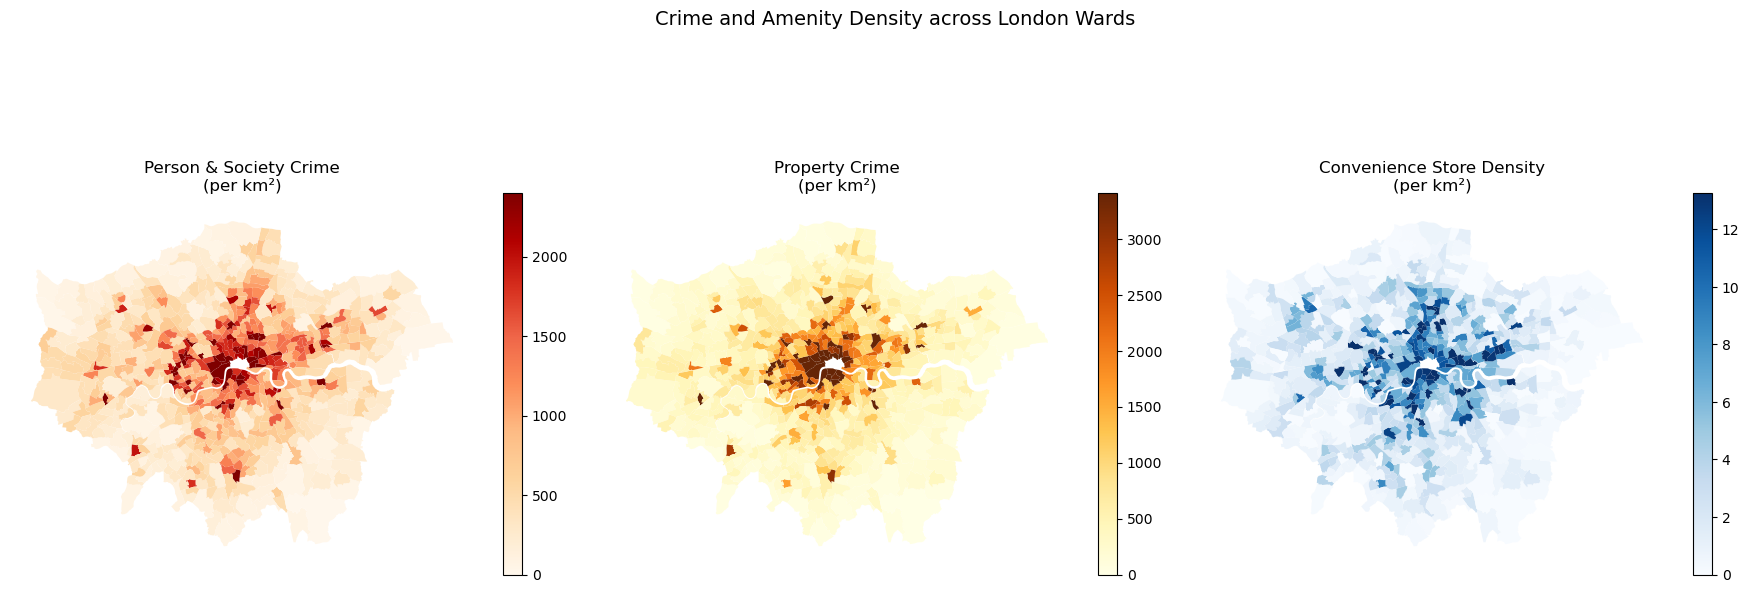

In [26]:
# ================================================================
# CELL 9 — Maps: Type A, Type B, and top POI density (fixed)
# ================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

plots = [
    ("typeA_density", "Person & Society Crime\n(per km²)", "OrRd"),
    ("typeB_density", "Property Crime\n(per km²)",         "YlOrBr"),
    ("convenience_density", "Convenience Store Density\n(per km²)", "Blues"),
]

for ax, (col, title, cmap) in zip(axes, plots):
    vmax = ward_gdf[col].quantile(0.95)
    ward_gdf.plot(
        column=col,
        cmap=cmap,
        legend=True,
        vmin=0,
        vmax=vmax,
        legend_kwds={"shrink": 0.6},
        ax=ax,
        missing_kwds={"color": "lightgrey"}
    )
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_axis_off()

plt.suptitle(
    "Crime and Amenity Density across London Wards",
    fontsize=14, y=1.01
)
plt.tight_layout()
plt.savefig("maps_crime_poi.png", dpi=150, bbox_inches="tight")
plt.show()

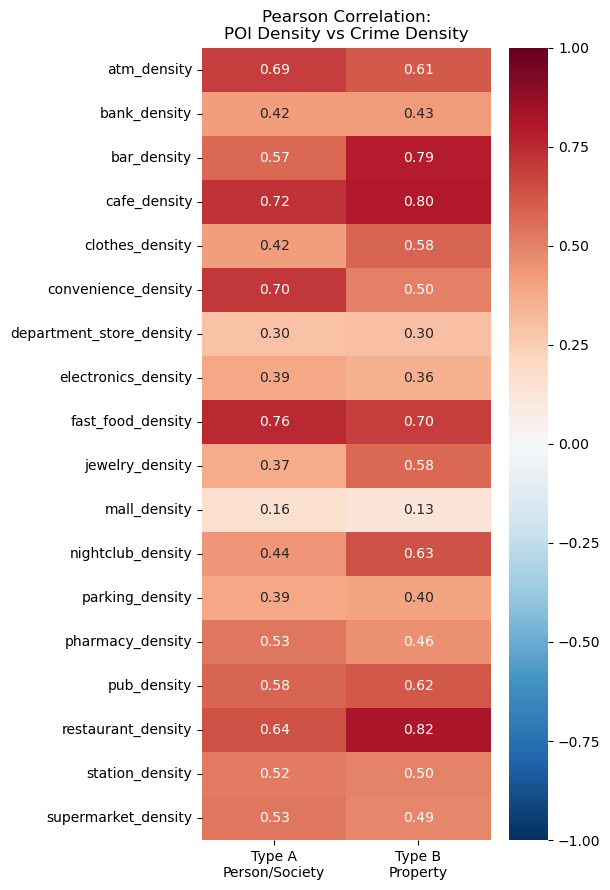


Top predictors for Type A (person/society crime):
fast_food_density           0.76
cafe_density                0.72
convenience_density         0.70
atm_density                 0.69
restaurant_density          0.64
pub_density                 0.58
bar_density                 0.57
pharmacy_density            0.53
supermarket_density         0.53
station_density             0.52
nightclub_density           0.44
bank_density                0.42
clothes_density             0.42
electronics_density         0.39
parking_density             0.39
jewelry_density             0.37
department_store_density    0.30
mall_density                0.16
Name: typeA_density, dtype: float64

Top predictors for Type B (property crime):
restaurant_density          0.82
cafe_density                0.80
bar_density                 0.79
fast_food_density           0.70
nightclub_density           0.63
pub_density                 0.62
atm_density                 0.61
clothes_density             0.58
jewelry_de

In [13]:
# ================================================================
# CELL 10 — Correlation heatmap: POI densities vs crime targets
# ================================================================
target_cols  = ["typeA_density", "typeB_density"]
feature_cols = poi_density_cols  # raw densities for interpretability

corr = ward_gdf[feature_cols + target_cols].corr()
corr_targets = corr.loc[feature_cols, target_cols]

fig, ax = plt.subplots(figsize=(6, 9))
sns.heatmap(
    corr_targets,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0,
    vmin=-1, vmax=1,
    xticklabels=["Type A\nPerson/Society", "Type B\nProperty"],
    ax=ax
)
ax.set_title("Pearson Correlation:\nPOI Density vs Crime Density", fontsize=12)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop predictors for Type A (person/society crime):")
print(corr_targets["typeA_density"].sort_values(ascending=False).round(2))
print("\nTop predictors for Type B (property crime):")
print(corr_targets["typeB_density"].sort_values(ascending=False).round(2))

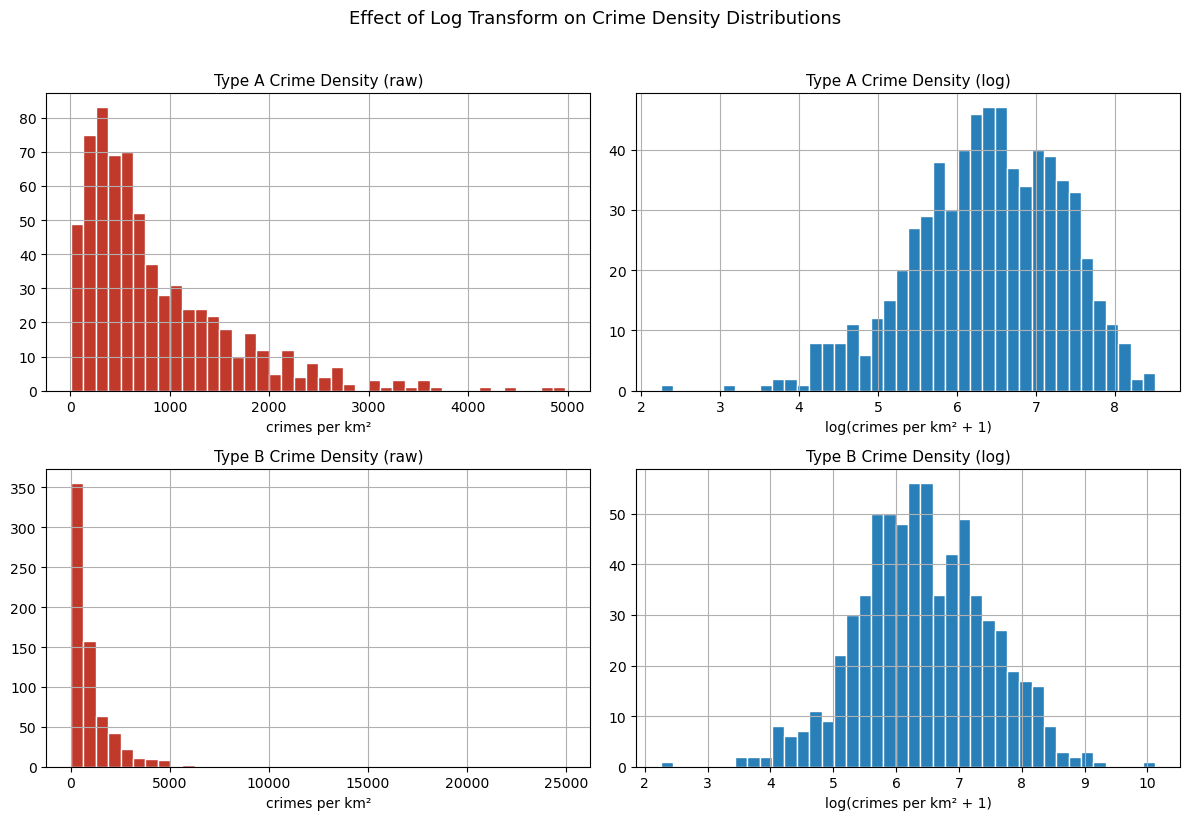

In [14]:
# ================================================================
# CELL 11 — Distribution plots: raw vs log transformed
# ================================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

pairs = [
    ("typeA_density",     "typeA_density_log",
     "Type A Crime Density (raw)", "Type A Crime Density (log)"),
    ("typeB_density",     "typeB_density_log",
     "Type B Crime Density (raw)", "Type B Crime Density (log)"),
]

for row, (raw, log, raw_title, log_title) in enumerate(pairs):
    ward_gdf[raw].hist(
        bins=40, ax=axes[row][0],
        color="#c0392b", edgecolor="white"
    )
    axes[row][0].set_title(raw_title, fontsize=11)
    axes[row][0].set_xlabel("crimes per km²")

    ward_gdf[log].hist(
        bins=40, ax=axes[row][1],
        color="#2980b9", edgecolor="white"
    )
    axes[row][1].set_title(log_title, fontsize=11)
    axes[row][1].set_xlabel("log(crimes per km² + 1)")

plt.suptitle(
    "Effect of Log Transform on Crime Density Distributions",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig("distributions.png", dpi=150, bbox_inches="tight")
plt.show()

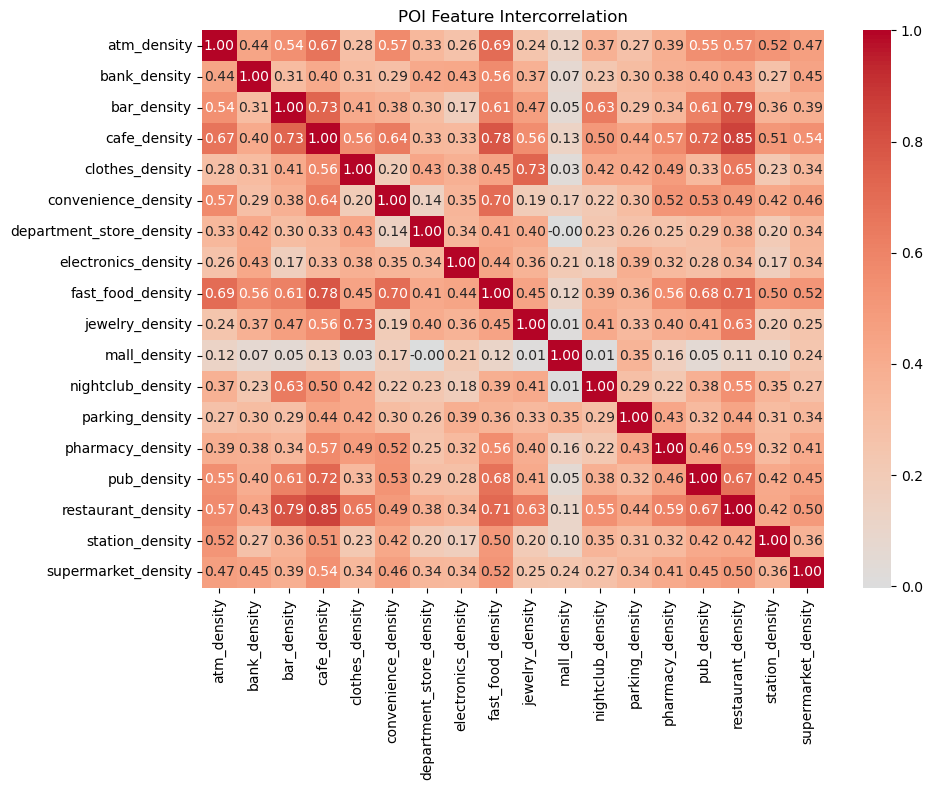

Highly correlated POI pairs (r > 0.8):
  cafe_density × restaurant_density: 0.85


In [15]:
# ================================================================
# CELL 12 — Multicollinearity check between POI features
# ================================================================
fig, ax = plt.subplots(figsize=(10, 8))
poi_corr = ward_gdf[feature_cols].corr()

sns.heatmap(
    poi_corr,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    ax=ax
)
ax.set_title("POI Feature Intercorrelation", fontsize=12)
plt.tight_layout()
plt.savefig("multicollinearity.png", dpi=150, bbox_inches="tight")
plt.show()

# Flag pairs above 0.8
high_corr = [
    (poi_corr.columns[i], poi_corr.columns[j], round(poi_corr.iloc[i,j], 2))
    for i in range(len(poi_corr.columns))
    for j in range(i+1, len(poi_corr.columns))
    if abs(poi_corr.iloc[i,j]) > 0.8
]

print("Highly correlated POI pairs (r > 0.8):")
for a, b, r in high_corr:
    print(f"  {a} × {b}: {r}")

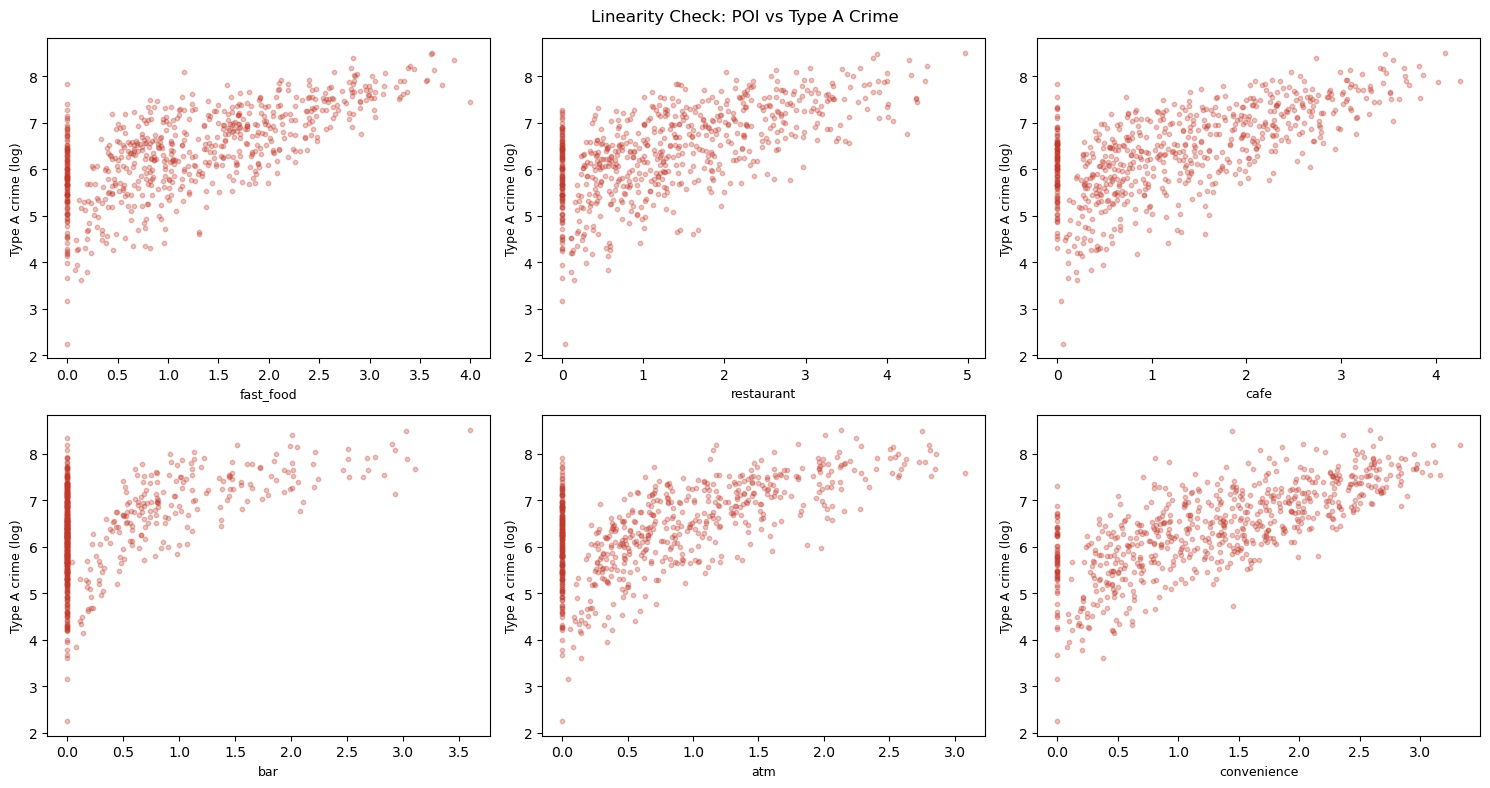

In [16]:
# Check if the relationship is actually non-linear
# If these scatter plots show curves rather than lines, RF will outperform MLR substantially

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

top_features = ["fast_food_density_log", "restaurant_density_log", 
                "cafe_density_log", "bar_density_log",
                "atm_density_log", "convenience_density_log"]

for ax, feat in zip(axes.flatten(), top_features):
    ax.scatter(
        ward_gdf[feat], 
        ward_gdf["typeA_density_log"],
        alpha=0.3, s=10, color="#c0392b"
    )
    ax.set_xlabel(feat.replace("_density_log", ""), fontsize=9)
    ax.set_ylabel("Type A crime (log)", fontsize=9)
    
plt.suptitle("Linearity Check: POI vs Type A Crime", fontsize=12)
plt.tight_layout()
plt.show()

In [27]:
# ================================================================
# CELL 13 — Feature setup + train/test split
# ================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

# Features and targets
feature_cols = log_feature_cols  # all POI density log-transformed
targetA      = "typeA_density_log"
targetB      = "typeB_density_log"

# Drop any rows with missing values
model_df = ward_gdf[feature_cols + [targetA, targetB]].dropna().copy()
print(f"Modelling dataset: {len(model_df)} wards")

X = model_df[feature_cols]
yA = model_df[targetA]
yB = model_df[targetB]

X_train, X_test, yA_train, yA_test, yB_train, yB_test = train_test_split(
    X, yA, yB, test_size=0.2, random_state=42
)

# Standardise for MLR and KNN (RF doesn't need it)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} wards")
print(f"Test:  {X_test.shape[0]} wards")
print(f"Features: {len(feature_cols)}")

Modelling dataset: 679 wards
Train: 543 wards
Test:  136 wards
Features: 18



MLR — Type A (person/society)
  R²:   0.521
  RMSE: 0.591


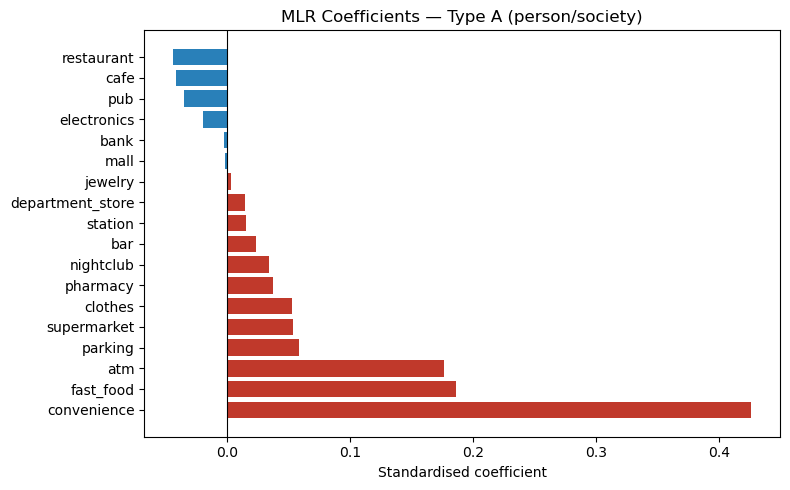


MLR — Type B (property)
  R²:   0.630
  RMSE: 0.585


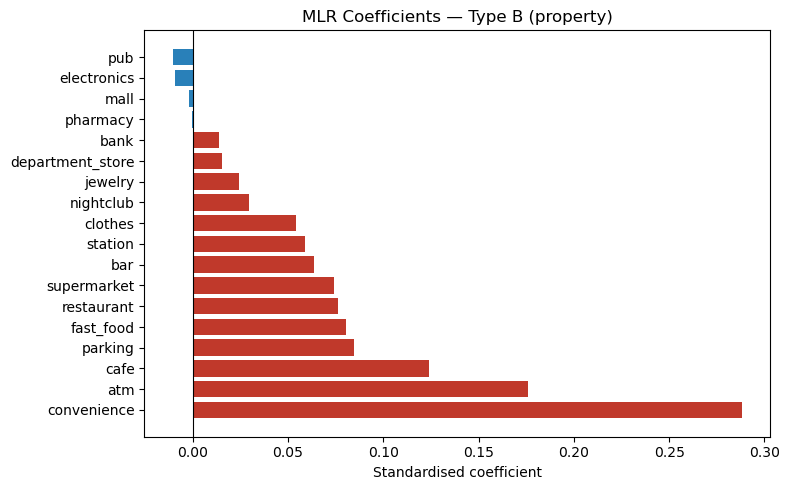

In [28]:
# ================================================================
# CELL 14 — Multiple Linear Regression
# ================================================================
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error



results = {}

for target_name, y_train, y_test in [
    ("Type A (person/society)", yA_train, yA_test),
    ("Type B (property)",       yB_train, yB_test)
]:
    mlr = LinearRegression()
    mlr.fit(X_train_sc, y_train)
    y_pred = mlr.predict(X_test_sc)

    r2   = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)

    results[f"MLR_{target_name}"] = {"R2": r2, "RMSE": rmse}
    print(f"\nMLR — {target_name}")
    print(f"  R²:   {r2:.3f}")
    print(f"  RMSE: {rmse:.3f}")

    # Coefficients
    coef_df = pd.DataFrame({
        "Feature":     [c.replace("_density_log","") for c in feature_cols],
        "Coefficient": mlr.coef_
    }).sort_values("Coefficient", ascending=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ["#c0392b" if c > 0 else "#2980b9" 
              for c in coef_df["Coefficient"]]
    ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"MLR Coefficients — {target_name}", fontsize=12)
    ax.set_xlabel("Standardised coefficient")
    plt.tight_layout()
    plt.savefig(f"mlr_coef_{target_name[:6]}.png", dpi=150)
    plt.show()

Best k: 11 (CV R²: 0.564)


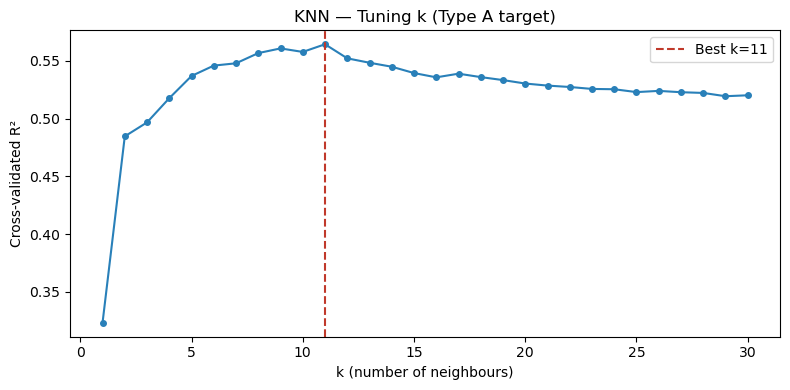


KNN (k=11) — Type A (person/society)
  R²:   0.404
  RMSE: 0.659

KNN (k=11) — Type B (property)
  R²:   0.535
  RMSE: 0.655


In [29]:
# ================================================================
# CELL 15 — KNN Regressor (tune k)
# ================================================================
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score

# Tune k for Type A
k_scores = []
for k in range(1, 31):
    knn = KNeighborsRegressor(n_neighbors=k)
    score = cross_val_score(
        knn, X_train_sc, yA_train, cv=5, scoring="r2"
    ).mean()
    k_scores.append(score)

best_k = k_scores.index(max(k_scores)) + 1
print(f"Best k: {best_k} (CV R²: {max(k_scores):.3f})")

# Plot k tuning
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 31), k_scores, marker="o", markersize=4,
        color="#2980b9", linewidth=1.5)
ax.axvline(best_k, color="#c0392b", linestyle="--",
           label=f"Best k={best_k}")
ax.set_xlabel("k (number of neighbours)")
ax.set_ylabel("Cross-validated R²")
ax.set_title("KNN — Tuning k (Type A target)", fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig("knn_tuning.png", dpi=150)
plt.show()

# Fit KNN with best k — both targets
for target_name, y_train, y_test in [
    ("Type A (person/society)", yA_train, yA_test),
    ("Type B (property)",       yB_train, yB_test)
]:
    knn = KNeighborsRegressor(n_neighbors=best_k)
    knn.fit(X_train_sc, y_train)
    y_pred = knn.predict(X_test_sc)

    r2   = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)

    results[f"KNN_{target_name}"] = {"R2": r2, "RMSE": rmse}
    print(f"\nKNN (k={best_k}) — {target_name}")
    print(f"  R²:   {r2:.3f}")
    print(f"  RMSE: {rmse:.3f}")


Random Forest — Type A (person/society)
  R²:   0.635
  RMSE: 0.516

Random Forest — Type B (property)
  R²:   0.714
  RMSE: 0.514

── Model Comparison ──
Method                  Target    R²  RMSE
    RF Type A (person/society) 0.635 0.516
   MLR Type A (person/society) 0.521 0.591
   KNN Type A (person/society) 0.404 0.659
    RF       Type B (property) 0.714 0.514
   MLR       Type B (property) 0.630 0.585
   KNN       Type B (property) 0.535 0.655


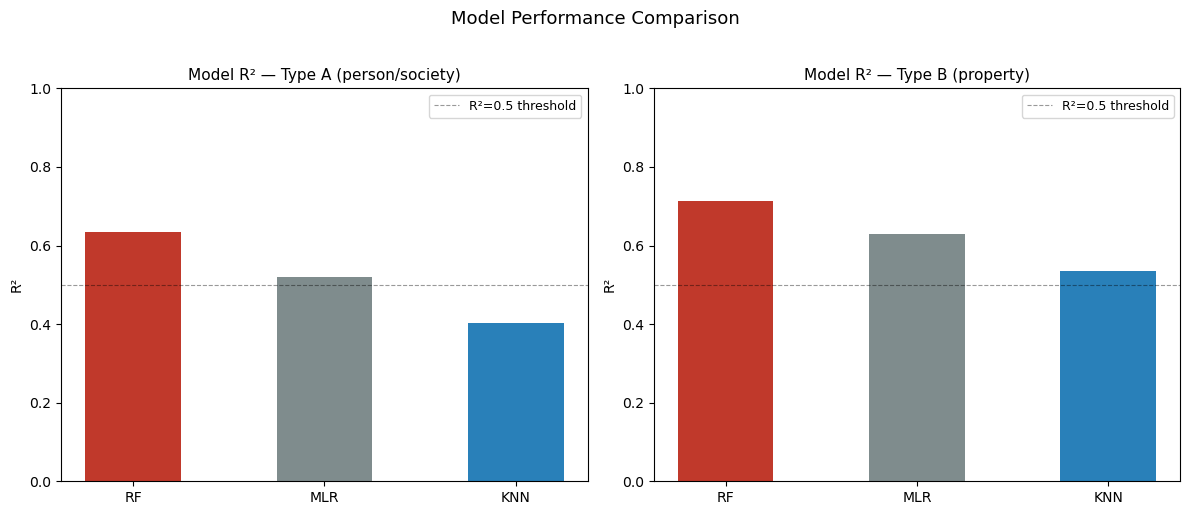

In [30]:
# ================================================================
# CELL 16 — Random Forest (tuned) + model comparison table
# ================================================================
from sklearn.ensemble import RandomForestRegressor

# Best params from yesterday's grid search
best_params = {
    "max_depth":        10,
    "min_samples_leaf": 4,
    "n_estimators":     300,
    "random_state":     42,
    "n_jobs":           -1
}

rf_models = {}

for target_name, y_train, y_test in [
    ("Type A (person/society)", yA_train, yA_test),
    ("Type B (property)",       yB_train, yB_test)
]:
    rf = RandomForestRegressor(**best_params)
    rf.fit(X_train, y_train)  # RF uses unscaled features
    y_pred = rf.predict(X_test)

    r2   = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)

    results[f"RF_{target_name}"] = {"R2": r2, "RMSE": rmse}
    rf_models[target_name] = rf

    print(f"\nRandom Forest — {target_name}")
    print(f"  R²:   {r2:.3f}")
    print(f"  RMSE: {rmse:.3f}")

# ── Model comparison table ──────────────────────────────────────
comparison_rows = []
for key, vals in results.items():
    method, target = key.split("_", 1)
    comparison_rows.append({
        "Method": method,
        "Target": target,
        "R²":     round(vals["R2"],   3),
        "RMSE":   round(vals["RMSE"], 3)
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    ["Target", "R²"], ascending=[True, False]
)
print("\n── Model Comparison ──")
print(comparison_df.to_string(index=False))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, target in zip(axes, [
    "Type A (person/society)", "Type B (property)"
]):
    subset = comparison_df[comparison_df["Target"] == target]
    colors = ["#c0392b" if m == "RF" else "#2980b9" if m == "KNN"
              else "#7f8c8d" for m in subset["Method"]]
    ax.bar(subset["Method"], subset["R²"], color=colors, width=0.5)
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color="black", linewidth=0.8,
               linestyle="--", alpha=0.4, label="R²=0.5 threshold")
    ax.set_title(f"Model R² — {target}", fontsize=11)
    ax.set_ylabel("R²")
    ax.legend(fontsize=9)

plt.suptitle("Model Performance Comparison", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()

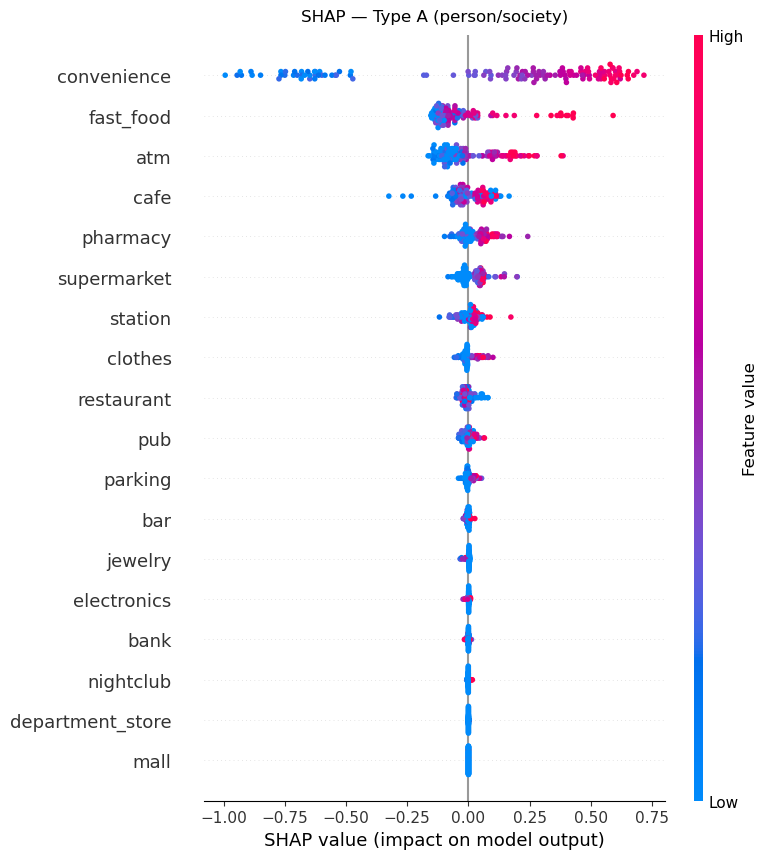

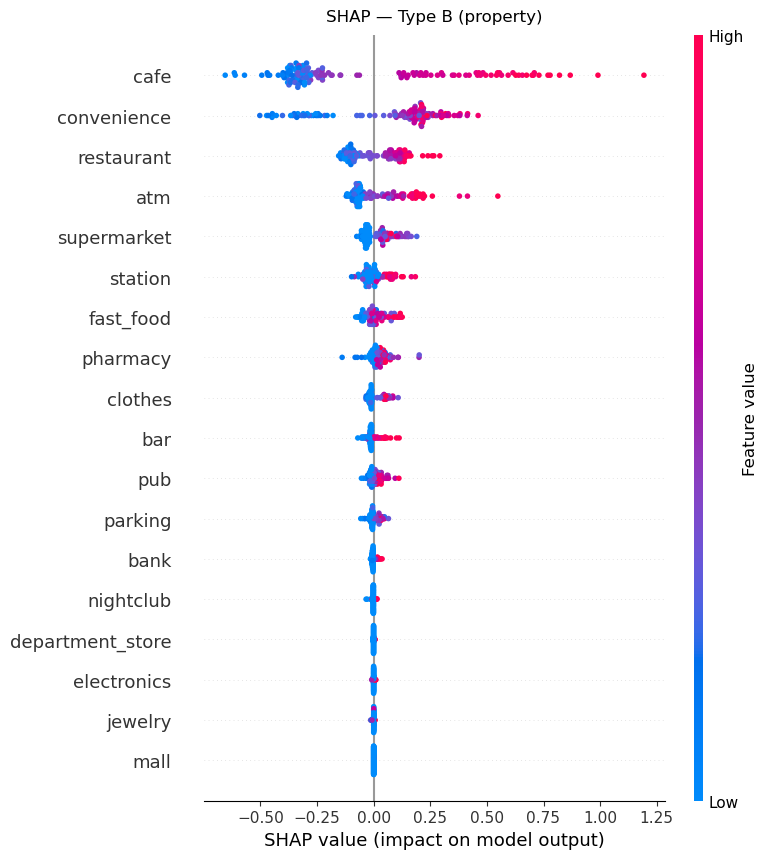

In [31]:
# ================================================================
# CELL 17 — SHAP: beeswarm plots (separate figures)
# ================================================================
import shap

clean_names = [c.replace("_density_log", "") for c in feature_cols]

for target_name, rf in rf_models.items():
    explainer = shap.TreeExplainer(rf)
    shap_vals = explainer.shap_values(X_test)

    plt.figure(figsize=(10, 7))
    shap.summary_plot(
        shap_vals,
        X_test,
        feature_names=clean_names,
        show=False
    )
    plt.title(f"SHAP — {target_name}", fontsize=12, pad=10)
    plt.tight_layout()
    plt.savefig(
        f"shap_{target_name[:6].strip()}.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show()
    plt.close()

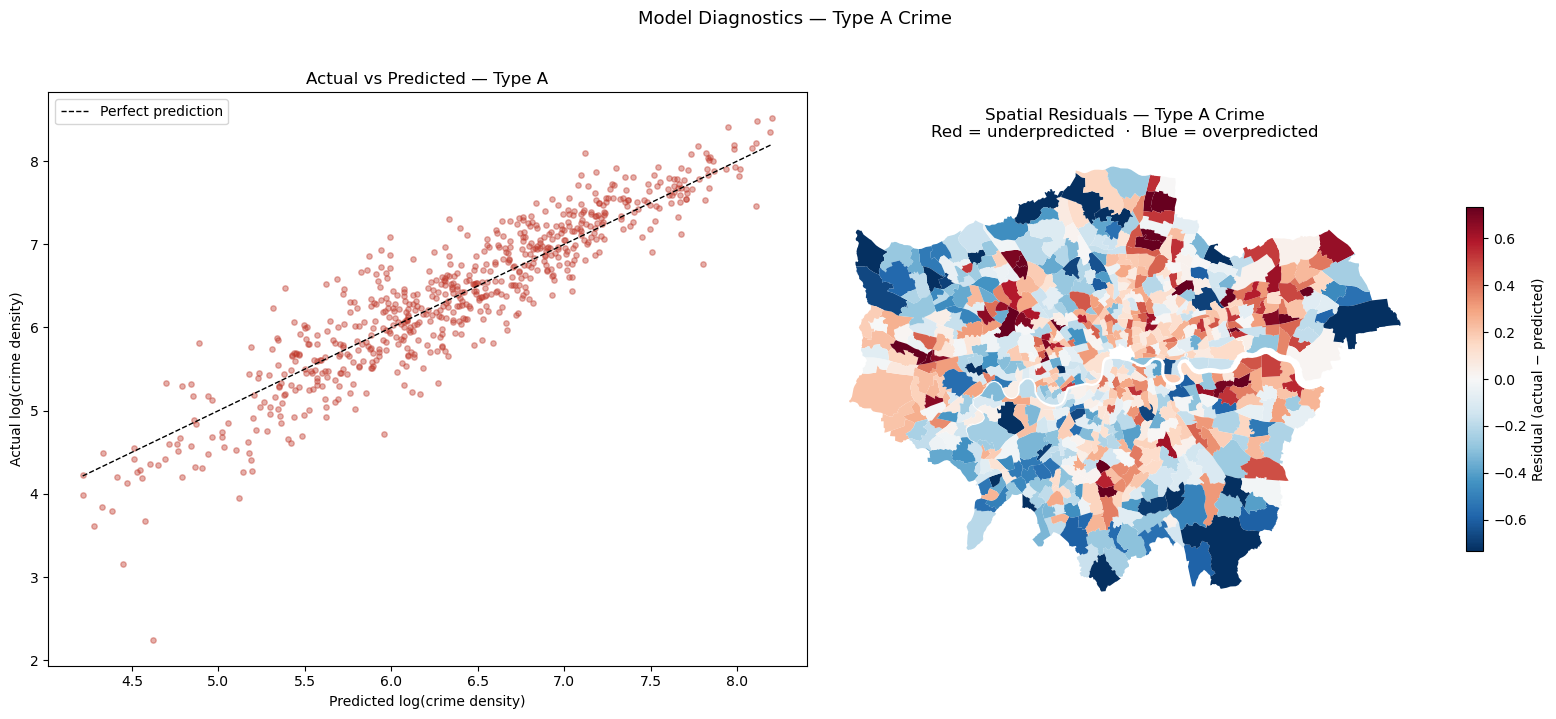


Worst underpredicted wards (model underestimates crime):
       WardName   Borough  residual_A
Colindale South    Barnet    1.100952
    Stonebridge     Brent    1.091442
 Edmonton Green   Enfield    0.990996
     Valentines Redbridge    0.984018
    Broad Green   Croydon    0.975585

Worst overpredicted wards (model overestimates crime):
    WardName                Borough  residual_A
      Darwin                Bromley   -2.372754
   Upminster               Havering   -1.294414
  Berrylands   Kingston upon Thames   -1.240345
 Cockfosters                Enfield   -1.167575
Queen's Gate Kensington and Chelsea   -1.037730


In [32]:
# ================================================================
# CELL 18 — Spatial residuals map
# ================================================================
rf_A = rf_models["Type A (person/society)"]
ward_gdf["typeA_pred_log"] = rf_A.predict(
    ward_gdf[feature_cols].fillna(0)
)
ward_gdf["residual_A"] = (
    ward_gdf["typeA_density_log"] - ward_gdf["typeA_pred_log"]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Actual vs predicted scatter
axes[0].scatter(
    ward_gdf["typeA_pred_log"],
    ward_gdf["typeA_density_log"],
    alpha=0.4, s=15, color="#c0392b"
)
mn = ward_gdf["typeA_pred_log"].min()
mx = ward_gdf["typeA_pred_log"].max()
axes[0].plot([mn, mx], [mn, mx], "k--", linewidth=1,
             label="Perfect prediction")
axes[0].set_xlabel("Predicted log(crime density)")
axes[0].set_ylabel("Actual log(crime density)")
axes[0].set_title("Actual vs Predicted — Type A", fontsize=12)
axes[0].legend()

# Residuals map
vmax = ward_gdf["residual_A"].abs().quantile(0.95)
ward_gdf.plot(
    column="residual_A",
    cmap="RdBu_r",
    legend=True,
    vmin=-vmax, vmax=vmax,
    legend_kwds={
        "label": "Residual (actual − predicted)",
        "shrink": 0.6
    },
    ax=axes[1],
    missing_kwds={"color": "lightgrey"}
)
axes[1].set_title(
    "Spatial Residuals — Type A Crime\n"
    "Red = underpredicted  ·  Blue = overpredicted",
    fontsize=12
)
axes[1].set_axis_off()

plt.suptitle("Model Diagnostics — Type A Crime", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("residuals_A.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nWorst underpredicted wards (model underestimates crime):")
print(ward_gdf.nlargest(5, "residual_A")[
    ["WardName", "Borough", "residual_A"]
].to_string(index=False))

print("\nWorst overpredicted wards (model overestimates crime):")
print(ward_gdf.nsmallest(5, "residual_A")[
    ["WardName", "Borough", "residual_A"]
].to_string(index=False))

In [ ]:
from pysal.lib import weights
from pysal.explore import esda

# Spatial weights from ward boundaries
w = weights.Queen.from_dataframe(ward_gdf)
w.transform = 'r'

# Moran's I on residuals
moran = esda.Moran(ward_gdf["residual_A"], w)
print(f"Moran's I: {moran.I:.3f}")
print(f"p-value: {moran.p_sim:.3f}")

ModuleNotFoundError: No module named 'pysal'